In [ ]:
!pip install pandas numpy matplotlib nltk scikit-fuzzy deep-translator vaderSentiment Sastrawi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from deep_translator import GoogleTranslator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
df = pd.read_csv("daily_sentiment.csv")
df.head(10)

,Date,Article,SentimentLabel
0,2025-11-12 16:18:00,kepala badan gizi nasional (bgn) dadan hindaya...,neutral
1,2025-11-12 15:45:00,pemerintah dikabarkan bakal menggelontorkan da...,negative
2,2025-11-12 13:27:00,program makan bergizi gratis (mbg) yang digaga...,negative
3,2025-11-12 13:21:00,kepala badan gizi nasional (bgn) dadan hindaya...,neutral
4,2025-11-11 19:31:40,kementerian perindustrian mencatat industri al...,neutral
5,2025-11-11 16:55:00,kalangan peternak ayam menyambut positif langk...,positive
6,2025-11-11 16:20:47,badan pengelola investasi daya anagata nusanta...,neutral
7,2025-11-11 15:25:00,pemerintah menyiapkan investasi besar senilai ...,positive
8,2025-11-11 15:10:00,menteri pertanian/kepala badan pangan nasional...,neutral
9,2025-11-11 14:50:00,"menteri koordinator bidang pangan, zulkifli ha...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            1127 non-null   object
 1   Article         1126 non-null   object
 2   SentimentLabel  1127 non-null   object
dtypes: object(3)
memory usage: 26.5+ KB


### Inset Lexicon

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# ===================================================================
# LOAD LEXICON INDONESIA - FIXED
# ===================================================================
df_neg_lexicon = pd.read_csv("negative.tsv", sep="\t")
df_pos_lexicon = pd.read_csv("positive.tsv", sep="\t")

# Gabungkan
df_lexicon = pd.concat([df_neg_lexicon, df_pos_lexicon])

# Konversi ke dictionary VADER
# *4 = scaling agar mirip magnitude lexicon VADER asli
lexicon_dict = {row["word"]: float(row["weight"]) * 4
                for _, row in df_lexicon.iterrows()}

# Masukkan ke analyzer
analyzer = SentimentIntensityAnalyzer()
analyzer.lexicon.update(lexicon_dict)

print("Loaded", len(lexicon_dict), "Indonesian lexicon entries.")

# ===================================================================
# CELL 6: INITIALIZE VADER
# ===================================================================
sia = analyzer

for t in df['Article'].head(10):
    print(t)
    print(analyzer.polarity_scores(t))
    print("-----")


# ===================================================================
# CELL 7 (DIPERBAIKI): HITUNG VADER SCORES
# ===================================================================
def get_vader_scores(text):
    if pd.isna(text):
        return pd.Series([0, 0, 0, 0])
    scores = sia.polarity_scores(str(text))
    return pd.Series([scores['neg'], scores['neu'], scores['pos'], scores['compound']])

# Gunakan df_artikel, bukan df
df[['neg', 'neu', 'pos', 'compound']] = df['Article'].apply(get_vader_scores)

print("DataFrame dengan skor VADER:")
print(df[['Article', 'neg', 'neu', 'pos', 'compound']].head(10))

# Untuk kemudahan, assign ke df
df = df.copy()

Loaded 9074 Indonesian lexicon entries.
kepala badan gizi nasional (bgn) dadan hindayana mengungkapkan rencana permintaan tambahan anggaran kepada kementerian keuangan di bawah pimpinan purbaya yudhi sadewa. hal tersebut diungkapkan dadan dalam rapat dengar pendapat (rdp) dengan komisi ix dpr di ruang rapat komisi ix dpr, senayan, jakarta, rabu (12/11/2025). dadan menjelaskan, awalnya banyak pihak yang meragukan penyerapan anggaran di bgn. namun, dari hitungannya, sejak bulan januari bgn sudah menyerap anggaran rp 52 miliar, februari 1,1 triliun, maret rp 1,8 triliun, dan april rp 2,5 triliun.sementara penyerapan anggaran bgn pada bulan ini sudah menyerap anggaran rp 43,47 triliun, yang mencakup 61,2% dari total pagu yang mencapai rp 71 triliun.adapun pagu anggaran untuk program mbg sudah terserap rp 36,23 triliun dari total pagu rp 51,2 triliun. sehingga anggaran yang tersisa hanya rp 14,97 triliun. dari proyeksi, menurut dadan, maka bgn membutuhkan tambahan anggaran senilai rp 14,53 

### Fuzzifikasi

In [ ]:
x = np.arange(0, 1.01, 0.01)

# === NEGATIVE (disesuaikan untuk data real) ===
neg_low  = fuzz.trapmf(x, [0.00, 0.00, 0.15, 0.35])
neg_mid  = fuzz.trimf(x, [0.25, 0.45, 0.65])
neg_high = fuzz.trapmf(x, [0.55, 0.75, 1.00, 1.00])

# === NEUTRAL (kunci: harus bisa tangkap neutral dengan baik) ===
neu_low  = fuzz.trapmf(x, [0.00, 0.00, 0.20, 0.40])
neu_mid  = fuzz.trimf(x, [0.30, 0.55, 0.80])    # Centered di 0.55
neu_high = fuzz.trapmf(x, [0.70, 0.85, 1.00, 1.00])

# === POSITIVE (mirror dari negative) ===
pos_low  = fuzz.trapmf(x, [0.00, 0.00, 0.15, 0.35])
pos_mid  = fuzz.trimf(x, [0.25, 0.45, 0.65])
pos_high = fuzz.trapmf(x, [0.55, 0.75, 1.00, 1.00])

# --- DEFINE ANTECEDENTS ---
pos = ctrl.Antecedent(x, 'pos')
neg = ctrl.Antecedent(x, 'neg')
neu = ctrl.Antecedent(x, 'neu')

pos['low']  = pos_low
pos['mid']  = pos_mid
pos['high'] = pos_high

neg['low']  = neg_low
neg['mid']  = neg_mid
neg['high'] = neg_high

neu['low']  = neu_low
neu['mid']  = neu_mid
neu['high'] = neu_high

# ===================================================================
# OUTPUT SENTIMENT (Balanced - tidak terlalu ekstrem)
# ===================================================================
sentiment_x = np.arange(0, 1.01, 0.01)
sentiment = ctrl.Consequent(sentiment_x, 'sentiment')

# Distribusi yang lebih balance
sentiment['negative'] = fuzz.trapmf(sentiment_x, [0.00, 0.00, 0.25, 0.45])
sentiment['neutral']  = fuzz.trimf(sentiment_x, [0.35, 0.50, 0.65])
sentiment['positive'] = fuzz.trapmf(sentiment_x, [0.55, 0.75, 1.00, 1.00])

print("✓ Fuzzifikasi balanced berhasil!")


✓ Fuzzifikasi balanced berhasil!


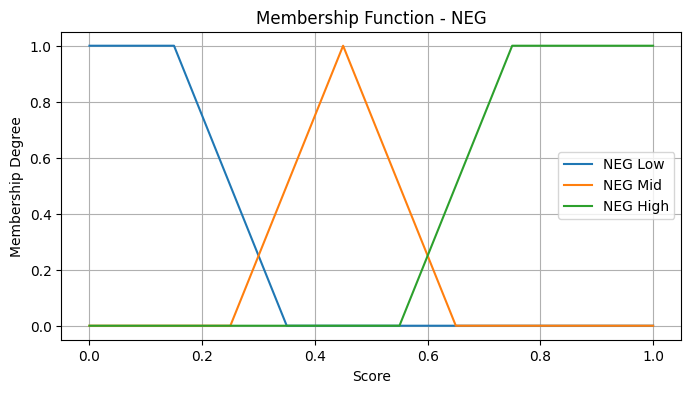

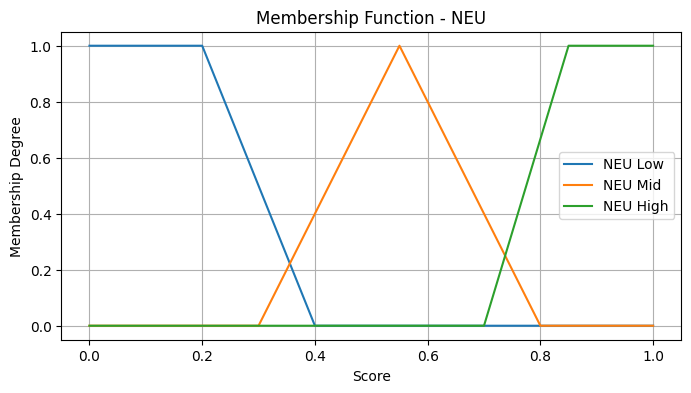

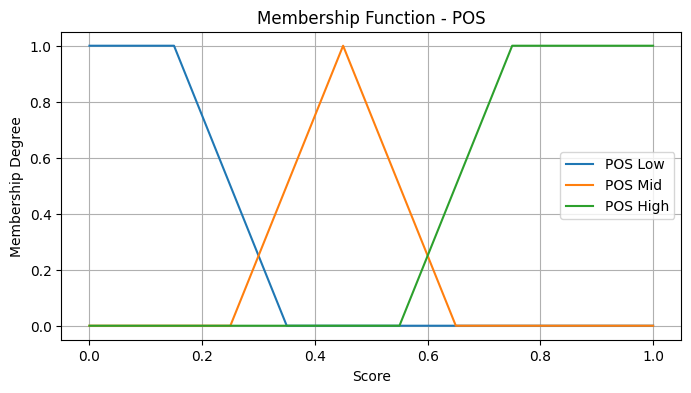

In [ ]:
# === Plot NEG ===
plt.figure(figsize=(8,4))
plt.plot(x, neg_low, label='NEG Low')
plt.plot(x, neg_mid, label='NEG Mid')
plt.plot(x, neg_high, label='NEG High')
plt.title('Membership Function - NEG')
plt.xlabel('Score')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()

# === Plot NEU ===
plt.figure(figsize=(8,4))
plt.plot(x, neu_low, label='NEU Low')
plt.plot(x, neu_mid, label='NEU Mid')
plt.plot(x, neu_high, label='NEU High')
plt.title('Membership Function - NEU')
plt.xlabel('Score')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()

# === Plot POS ===
plt.figure(figsize=(8,4))
plt.plot(x, pos_low, label='POS Low')
plt.plot(x, pos_mid, label='POS Mid')
plt.plot(x, pos_high, label='POS High')
plt.title('Membership Function - POS')
plt.xlabel('Score')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()


### Rule Base Fuzzy

In [ ]:
# ===================================================================
# RULES – Versi 27 Rule (3×3×3) – Single Block
# ===================================================================
rules = []

# =========================
#   POSITIVE
# =========================
rules.append(ctrl.Rule(pos['high'] & neu['high'] & neg['low'], sentiment['positive']))
rules.append(ctrl.Rule(pos['high'] & neu['mid']  & neg['low'], sentiment['positive']))
rules.append(ctrl.Rule(pos['high'] & neu['low']  & neg['mid'], sentiment['positive']))
rules.append(ctrl.Rule(pos['high'] & neu['low']  & neg['low'], sentiment['positive']))
rules.append(ctrl.Rule(pos['mid']  & neu['mid']  & neg['low'], sentiment['positive']))
rules.append(ctrl.Rule(pos['mid']  & neu['low']  & neg['low'], sentiment['positive']))

# =========================
#   NEUTRAL
# =========================
rules.append(ctrl.Rule(pos['high'] & neu['high'] & neg['high'], sentiment['neutral']))
rules.append(ctrl.Rule(pos['high'] & neu['high'] & neg['mid'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['high'] & neu['mid']  & neg['mid'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['high'] & neu['low']  & neg['high'], sentiment['neutral']))
rules.append(ctrl.Rule(pos['mid']  & neu['mid']  & neg['mid'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['mid']  & neu['high'] & neg['mid'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['mid']  & neu['high'] & neg['low'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['mid']  & neu['low']  & neg['mid'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['low']  & neu['high'] & neg['mid'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['low']  & neu['mid']  & neg['mid'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['low']  & neu['mid']  & neg['low'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['low']  & neu['high'] & neg['low'],  sentiment['neutral']))
rules.append(ctrl.Rule(pos['low']  & neu['low']  & neg['low'],  sentiment['neutral']))

# =========================
#   NEGATIVE
# =========================
rules.append(ctrl.Rule(pos['high'] & neu['mid']  & neg['high'], sentiment['negative']))
rules.append(ctrl.Rule(pos['mid']  & neu['high'] & neg['high'], sentiment['negative']))
rules.append(ctrl.Rule(pos['mid']  & neu['mid']  & neg['high'], sentiment['negative']))
rules.append(ctrl.Rule(pos['mid']  & neu['low']  & neg['high'], sentiment['negative']))
rules.append(ctrl.Rule(pos['low']  & neu['high'] & neg['high'], sentiment['negative']))
rules.append(ctrl.Rule(pos['low']  & neu['mid']  & neg['high'], sentiment['negative']))
rules.append(ctrl.Rule(pos['low']  & neu['low']  & neg['high'], sentiment['negative']))
rules.append(ctrl.Rule(pos['low']  & neu['low']  & neg['mid'],  sentiment['negative']))

print("27 fuzzy rules berhasil dimuat!")


27 fuzzy rules berhasil dimuat!


### Inferensi

In [ ]:
# ===================================================================
# BUILD CONTROL SYSTEM
# ===================================================================
sentiment_ctrl = ctrl.ControlSystem(rules)
sentiment_sim = ctrl.ControlSystemSimulation(sentiment_ctrl)
print("Control system improved : 27 rules berhasil dibuat!")

Control system improved : 27 rules berhasil dibuat!


### Defuzzifikasi

In [ ]:
def predict_sentiment_improved(row):
    """
    Fungsi prediksi dengan threshold adjustment
    """
    try:
        sentiment_sim.reset()

        sentiment_sim.input['pos'] = float(row['pos'])
        sentiment_sim.input['neg'] = float(row['neg'])
        sentiment_sim.input['neu'] = float(row['neu'])

        sentiment_sim.compute()
        score = sentiment_sim.output['sentiment']

        # === ADJUSTED THRESHOLDS (berdasarkan analisis distribusi) ===
        # Threshold ini bisa di-tune lebih lanjut
        if score < 0.40:
            return "negative", score
        elif score < 0.63:
            return "neutral", score
        else:
            return "positive", score

    except Exception as e:
        print(f"Error: {e}")
        return "neutral", 0.5  # fallback

# Apply prediction
predicted_labels = []
fuzzy_scores = []

for i, row in df.iterrows():
    label, score = predict_sentiment_improved(row)
    predicted_labels.append(label)
    fuzzy_scores.append(score)

df['FuzzyLabel_Improved'] = predicted_labels
df['FuzzyScore_Improved'] = fuzzy_scores

print(f"\nPrediksi improved selesai! Total: {len(df)} baris")



Prediksi improved selesai! Total: 1127 baris


#### Bobot hasil training optuna (tidak dipakai)

In [ ]:
# # ================================
# # Bobot & threshold terbaru (Optuna)
# # ================================
# W_POS = 0.3914238553546123
# W_NEG = 0.18253207526765783
# W_NEU = 0.9027034579302549

# T1 = 0.3499651352118693
# T2 = 0.6622415196458487

# # ================================
# # Fungsi prediksi (versi update)
# # ================================
# def predict_sentiment_improved(row):
#     """
#     Fungsi prediksi dengan bobot fuzzy terbaru + threshold hasil training
#     """
#     try:
#         sentiment_sim.reset()

#         # Input untuk fuzzy engine
#         sentiment_sim.input['pos'] = float(row['pos'])
#         sentiment_sim.input['neg'] = float(row['neg'])
#         sentiment_sim.input['neu'] = float(row['neu'])

#         sentiment_sim.compute()

#         # Skor fuzzy asli
#         base_score = sentiment_sim.output['sentiment']

#         # Skor berbobot (hasil Optuna terbaru)
#         weighted_score = (
#             W_POS * float(row['pos']) +
#             W_NEG * float(row['neg']) +
#             W_NEU * float(row['neu'])
#         )

#         # Kombinasi skor
#         score = 0.5 * base_score + 0.5 * weighted_score

#         # Threshold teroptimasi
#         if score < T1:
#             return "negative", score
#         elif score < T2:
#             return "neutral", score
#         else:
#             return "positive", score

#     except Exception as e:
#         print(f"Error: {e}")
#         return "neutral", 0.5

# # ================================
# # Apply prediction
# # ================================
# predicted_labels = []
# fuzzy_scores = []

# for i, row in df.iterrows():
#     label, score = predict_sentiment_improved(row)
#     predicted_labels.append(label)
#     fuzzy_scores.append(score)

# df['FuzzyLabel_Improved'] = predicted_labels
# df['FuzzyScore_Improved'] = fuzzy_scores

# print(f"\nPrediksi improved (versi terbaru) selesai! Total: {len(df)} baris")


#### Evaluasi akhir

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n=== EVALUASI FUZZY IMPROVED ===")
print("\nConfusion Matrix:")
print(confusion_matrix(df['SentimentLabel'], df['FuzzyLabel_Improved']))
print("\nClassification Report:")
print(classification_report(df['SentimentLabel'], df['FuzzyLabel_Improved']))


=== EVALUASI FUZZY IMPROVED ===

Confusion Matrix:
[[ 21 130   1]
 [ 32 556 152]
 [ 10 207  18]]

Classification Report:
              precision    recall  f1-score   support

    negative       0.33      0.14      0.20       152
     neutral       0.62      0.75      0.68       740
    positive       0.11      0.08      0.09       235

    accuracy                           0.53      1127
   macro avg       0.35      0.32      0.32      1127
weighted avg       0.48      0.53      0.49      1127



### Evaluasi

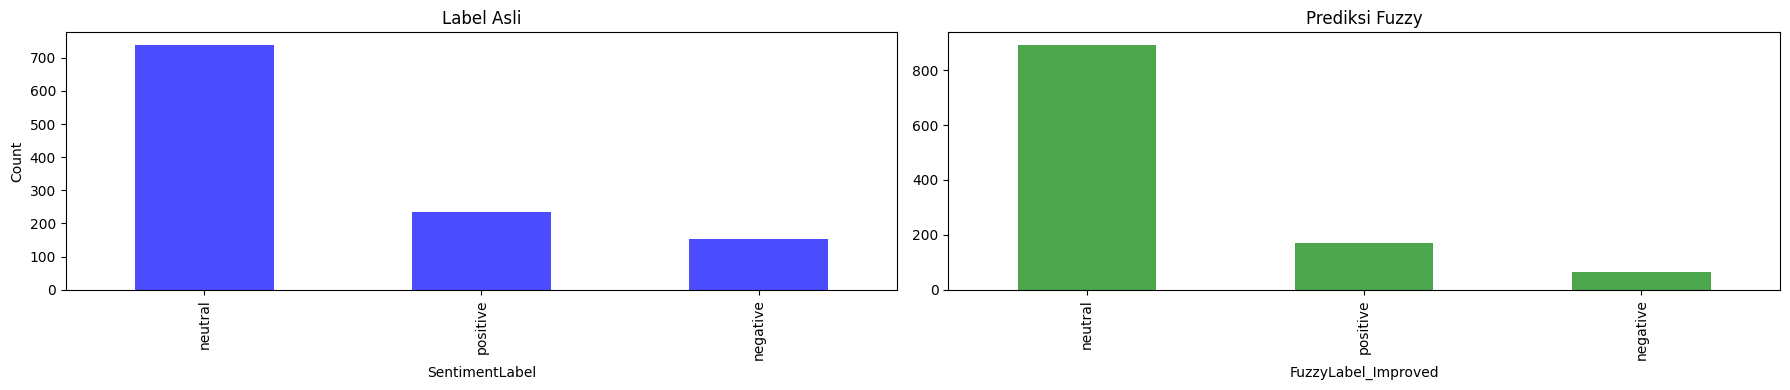

In [ ]:
# ===================================================================
# VISUALISASI
# ===================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# Original
df['SentimentLabel'].value_counts().plot(kind='bar', ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('Label Asli')
axes[0].set_ylabel('Count')

# Fuzzy
df['FuzzyLabel_Improved'].value_counts().plot(kind='bar', ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('Prediksi Fuzzy')

plt.tight_layout()
plt.show()

In [ ]:
# ===================================================================
# TABEL DESKRIPSI
# ===================================================================

# Hitung distribusi asli
orig_counts = df['SentimentLabel'].value_counts().rename("Original_Count")
orig_percent = (df['SentimentLabel'].value_counts(normalize=True) * 100).rename("Original_%")

# Hitung distribusi fuzzy
fuzzy_counts = df['FuzzyLabel_Improved'].value_counts().rename("Fuzzy_Count")
fuzzy_percent = (df['FuzzyLabel_Improved'].value_counts(normalize=True) * 100).rename("Fuzzy_%")

# Gabungkan dalam satu tabel
summary_table = pd.concat([orig_counts, orig_percent, fuzzy_counts, fuzzy_percent], axis=1)

# Tampilkan tabel
print("\n=== DESKRIPSI DISTRIBUSI LABEL (ASLI vs FUZZY) ===")
print(summary_table)



=== DESKRIPSI DISTRIBUSI LABEL (ASLI vs FUZZY) ===
          Original_Count  Original_%  Fuzzy_Count    Fuzzy_%
neutral              740   65.661047          893  79.236912
positive             235   20.851819          171  15.173026
negative             152   13.487134           63   5.590062


In [ ]:
df[['Article', 'compound', 'SentimentLabel', 'FuzzyLabel_Improved']].head(20)


,Article,compound,SentimentLabel,FuzzyLabel_Improved
0,kepala badan gizi nasional (bgn) dadan hindaya...,-0.9942,neutral,neutral
1,pemerintah dikabarkan bakal menggelontorkan da...,-0.9998,negative,neutral
2,program makan bergizi gratis (mbg) yang digaga...,-0.9999,negative,neutral
3,kepala badan gizi nasional (bgn) dadan hindaya...,0.9987,neutral,neutral
4,kementerian perindustrian mencatat industri al...,0.9992,neutral,positive
5,kalangan peternak ayam menyambut positif langk...,-0.9998,positive,neutral
6,badan pengelola investasi daya anagata nusanta...,0.9988,neutral,neutral
7,pemerintah menyiapkan investasi besar senilai ...,-0.9998,positive,neutral
8,menteri pertanian/kepala badan pangan nasional...,0.9999,neutral,neutral
9,"menteri koordinator bidang pangan, zulkifli ha...",-0.9990,positive,neutral


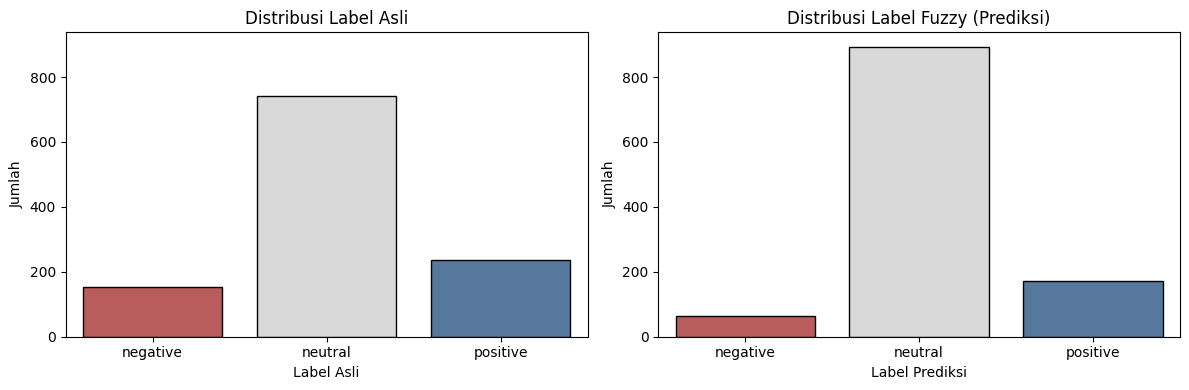

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Urutan label tetap
order_labels = ['negative', 'neutral', 'positive']

# Palet warna matte
palette = {
    'negative': '#c94c4c',
    'neutral':  '#d9d9d9',
    'positive': '#4a78a8'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot label asli
ax1 = sns.countplot(
    data=df,
    x='SentimentLabel',
    hue='SentimentLabel',
    order=order_labels,
    palette=palette,
    edgecolor='black',
    linewidth=1,
    legend=False,
    ax=axes[0]
)

# Plot label fuzzy
ax2 = sns.countplot(
    data=df,
    x='FuzzyLabel_Improved',
    hue='FuzzyLabel_Improved',
    order=order_labels,
    palette=palette,
    edgecolor='black',
    linewidth=1,
    legend=False,
    ax=axes[1]
)

# ===== Samakan skala Y =====
max_count_1 = max([p.get_height() for p in ax1.patches])
max_count_2 = max([p.get_height() for p in ax2.patches])
max_y = max(max_count_1, max_count_2)

axes[0].set_ylim(0, max_y * 1.05)
axes[1].set_ylim(0, max_y * 1.05)

# Label
axes[0].set_title("Distribusi Label Asli")
axes[0].set_xlabel("Label Asli")
axes[0].set_ylabel("Jumlah")

axes[1].set_title("Distribusi Label Fuzzy (Prediksi)")
axes[1].set_xlabel("Label Prediksi")
axes[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()


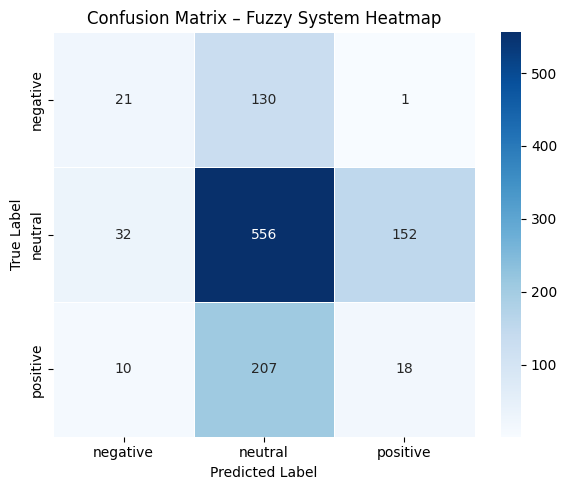

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ambil label unik dari data
true_labels = df['SentimentLabel'].astype(str).unique()
pred_labels = df['FuzzyLabel_Improved'].astype(str).unique()

# gabungkan dan urutkan supaya konsisten
labels = np.union1d(true_labels, pred_labels)

# hitung confusion matrix
cm = confusion_matrix(df['SentimentLabel'], df['FuzzyLabel_Improved'], labels=labels)

# normalisasi per baris
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1)

# plot
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white')

ax.set_title("Confusion Matrix – Fuzzy System Heatmap")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()



### Training Optuna (tidak dipakai)

In [ ]:
# !pip install optuna

# import optuna
# import numpy as np
# from sklearn.metrics import f1_score

# # ======================
# # TRUE LABEL mapping
# # ======================
# label_map = {
#     'negative': 0,
#     'neutral':  1,
#     'positive': 2
# }

# y_true = df['SentimentLabel'].map(label_map).values

# # ======================
# # Fungsi fuzzy score berbobot
# # ======================
# def weighted_fuzzy_score(row, w_pos, w_neg, w_neu):
#     return (
#         w_pos * row['pos'] +
#         w_neg * row['neg'] +
#         w_neu * row['neu']
#     )

# # ======================
# # Threshold-based prediction
# # ======================
# def predict_weighted(row, w_pos, w_neg, w_neu, t1, t2):
#     score = weighted_fuzzy_score(row, w_pos, w_neg, w_neu)
#     if score < t1:
#         return 0   # negative
#     elif score < t2:
#         return 1   # neutral
#     else:
#         return 2   # positive

# # ======================
# # Objective function (Optuna)
# # ======================
# def objective(trial):
#     # Bobot fuzzy
#     w_pos = trial.suggest_float("w_pos", 0.0, 1.0)
#     w_neg = trial.suggest_float("w_neg", 0.0, 1.0)
#     w_neu = trial.suggest_float("w_neu", 0.0, 1.0)

#     # Threshold
#     t1 = trial.suggest_float("t1", 0.2, 0.5)
#     t2 = trial.suggest_float("t2", 0.5, 0.8)

#     y_pred = []
#     for _, row in df.iterrows():
#         y_pred.append(predict_weighted(row, w_pos, w_neg, w_neu, t1, t2))

#     return f1_score(y_true, y_pred, average='macro')

# # ======================
# # Jalankan training
# # ======================
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=5000)

# # ======================
# # Hasil terbaik
# # ======================
# print("Best parameters found:")
# print(study.best_params)

# print("Best F1-score:")
# print(study.best_value)


In [ ]:
# ## MODIFIKASI WEIGHTS

# # ================================
# # Best parameters dari Optuna
# # ================================
# W_POS = 0.8836022371061177
# W_NEG = 0.09474973770758408
# W_NEU = 0.1436911504323673

# T1 = 0.38960961232222124
# T2 = 0.5303369268191754

# # ================================
# # Fungsi fuzzy score berbobot
# # ================================
# def weighted_fuzzy_score(row):
#     return (
#         W_POS * float(row['pos']) +
#         W_NEG * float(row['neg']) +
#         W_NEU * float(row['neu'])
#     )

# # ================================
# # Fungsi prediksi baru
# # ================================
# def predict_sentiment_optimized(row):
#     try:
#         score = weighted_fuzzy_score(row)

#         if score < T1:
#             return "negative", score
#         elif score < T2:
#             return "neutral", score
#         else:
#             return "positive", score

#     except Exception as e:
#         print(f"Error: {e}")
#         return "neutral", 0.5

# # ================================
# # Apply ke dataframe
# # ================================
# predicted_labels = []
# fuzzy_scores = []

# for _, row in df.iterrows():
#     label, score = predict_sentiment_optimized(row)
#     predicted_labels.append(label)
#     fuzzy_scores.append(score)

# df['FuzzyLabel_Optimized'] = predicted_labels
# df['FuzzyScore_Optimized'] = fuzzy_scores

# print("Prediksi dengan bobot Optuna selesai!")
# print(df[['pos','neg','neu','FuzzyLabel_Optimized','FuzzyScore_Optimized']].head())


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix

# # Urutan label tetap
# labels = ['negative', 'neutral', 'positive']

# # Ambil label asli & prediksi
# y_true = df['SentimentLabel'].astype(str)
# y_pred = df['FuzzyLabel_Improved'].astype(str)

# # Confusion matrix (JUMLAH / COUNT)
# cm = confusion_matrix(y_true, y_pred, labels=labels)

# # Plot heatmap dengan angka asli (bukan persentase)
# plt.figure(figsize=(6, 5))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",           # integer
#     cmap="Blues",
#     xticklabels=labels,
#     yticklabels=labels
# )

# plt.title("Confusion Matrix (Counts) - Fuzzy Improved")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()
# plt.show()
